# Phase 1 - Heart Disease Prediction

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Problem Understanding & Data Exploration)  
**Dataset:** Heart Disease Dataset (Kaggle)

This notebook covers:
- Introduction & Problem Statement
- Dataset Selection & Justification
- Initial Data Inspection
- Exploratory Data Analysis (with visualizations)
- Preprocessing Pipeline (with justifications)
- Preprocessed Dataset Ready for Modeling
- Key Insights & Challenges


## 1) Introduction & Problem Statement

Heart disease remains one of the leading causes of death worldwide, making early diagnosis essential for improving patient survival and reducing complications. Many cardiovascular conditions develop silently over time, meaning patients may not receive treatment until severe symptoms appear.
The objective of this project is to build a machine learning-based medical prediction system that classifies whether a patient is likely to have heart disease based on clinical and demographic measurements. Such a system can support early risk assessment and assist healthcare professionals in prioritizing further medical evaluation.
This project falls under the healthcare domain, and it aligns with the course goal of developing a supervised classification advice system during Phase 1.



## 2) Dataset Selection & Justification

**Source (Kaggle):** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

The goal of this dataset is to support medical risk prediction and binary classification, where the task is to determine whether a patient has heart disease based on clinical and demographic measurements. It is commonly used for developing supervised learning models for cardiovascular disease detection.

The dataset is structured in a tabular format and contains **1,025 patient records** with **13 medical features**, in addition to a binary target variable (`target`), where 0 indicates no heart disease and 1 indicates the presence of heart disease.

This dataset was selected because it is clinically relevant, well-structured, and meets Phase 1 requirements in terms of dataset size, feature complexity, and classification classes.

Additionally, the dataset demonstrates high quality and completeness, as it contains no missing values and provides a balanced distribution between the two target classes. These characteristics make it reliable for exploratory analysis and effective supervised learning model development.


## 3) Initial Data Inspection

In [32]:
# Install required libraries for reading Excel files, preprocessing data and plotting
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install openpyxl
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.1 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.0 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.0 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.0 MB 1.4 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.0 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.0 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/8.0 MB 1.4 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.0 MB 1.4 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.0 MB 1.4 MB/s eta 0:00:04
   ------------------ -----------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np

# Load dataset

DATA_PATH = "Dataset/Copy of heart.xlsx"   


df = pd.read_excel(DATA_PATH)

print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [22]:
# Basic info: columns, dtypes, nulls (quick scan)
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nPreview of target distribution:")
print(df["target"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Preview of target distribution:
target
1    526
0    499
Name: count, dtype: int64


## 4) Missing Values

Total missing values: 0


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


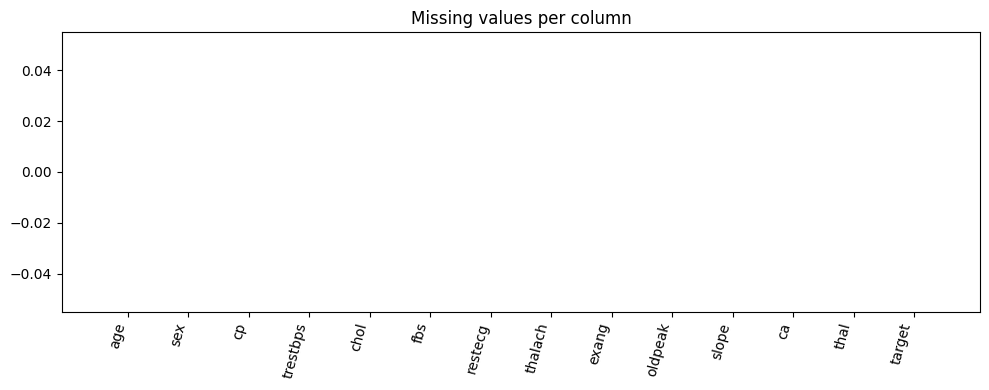

In [24]:
## 4) Missing Values
# Visualize missing values (bar plot)
import matplotlib.pyplot as plt

missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = int(missing_per_col.sum())

print("Total missing values:", total_missing)
display(missing_per_col.to_frame("missing_count").head(20))

plt.figure(figsize=(10,4))
plt.bar(missing_per_col.index, missing_per_col.values)
plt.xticks(rotation=75, ha="right")
plt.title("Missing values per column")
plt.tight_layout()
plt.show()

The dataset was successfully loaded in Python using Pandas.
Initial inspection confirmed:
1,025 observations
14 columns (13 features + target)
No missing values across all columns
The dataset includes both numerical measurements and encoded categorical clinical attributes.

## 5) Target Class Distribution

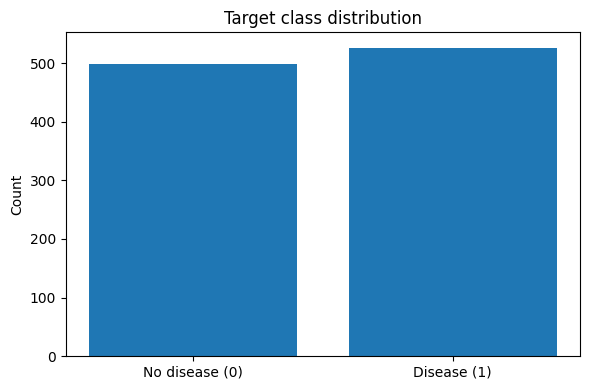

Counts:
target
0    499
1    526
Name: count, dtype: int64

Class balance (%):
target
0    48.68
1    51.32
Name: count, dtype: float64


In [25]:
## 5) Target Class Distribution

import matplotlib.pyplot as plt

counts = df["target"].value_counts().sort_index()
labels = ["No disease (0)", "Disease (1)"]

plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title("Target class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Counts:")
print(counts)
print("\nClass balance (%):")
print((counts / counts.sum() * 100).round(2))

## 6) Descriptive Statistics

We compute summary statistics (mean, std, min/max, quartiles) to understand the ranges and variability of numeric features.


In [26]:
# Descriptive statistics for numeric columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 7) Feature Distributions (Histograms)

Histograms show how each numeric feature is distributed across the dataset.


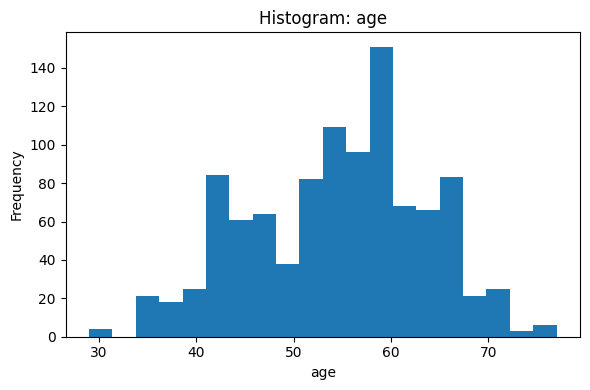

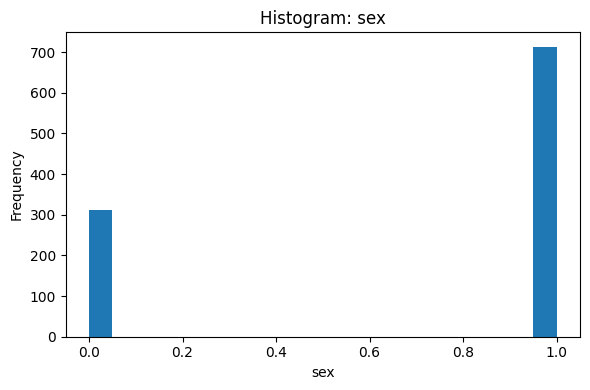

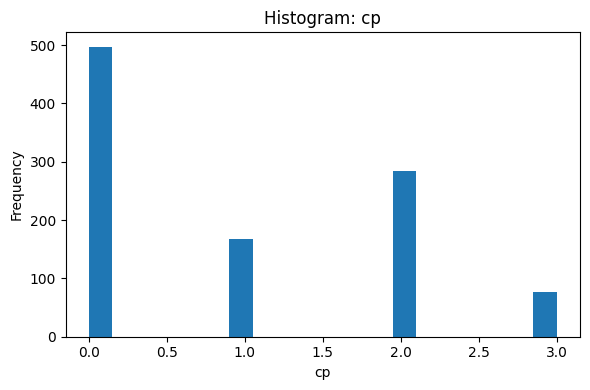

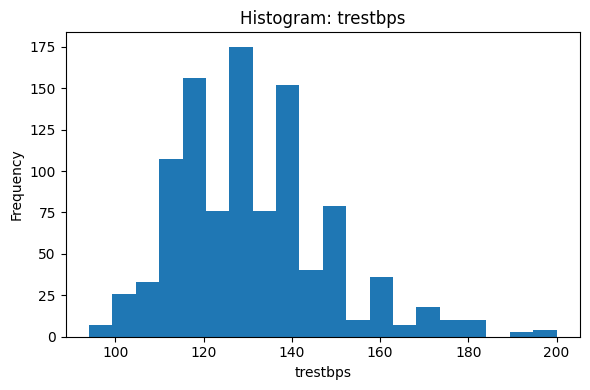

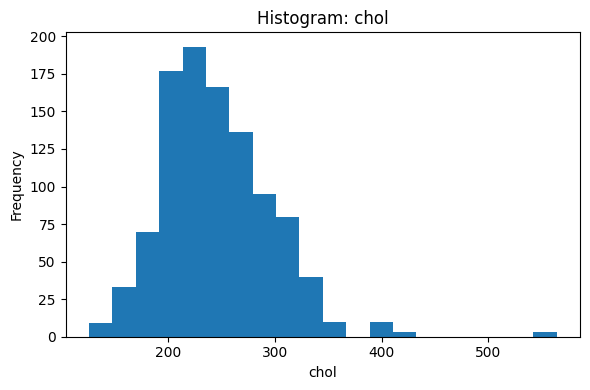

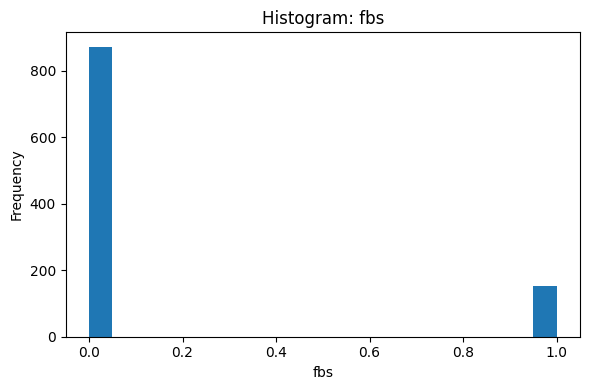

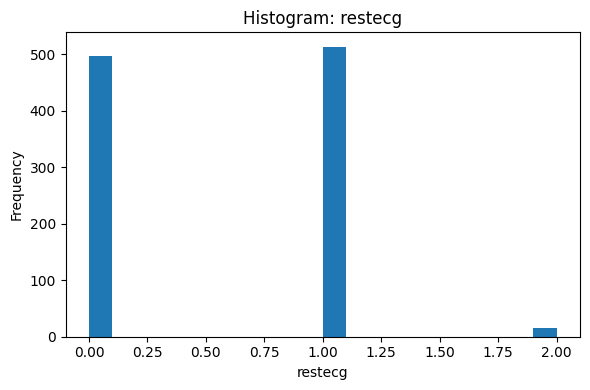

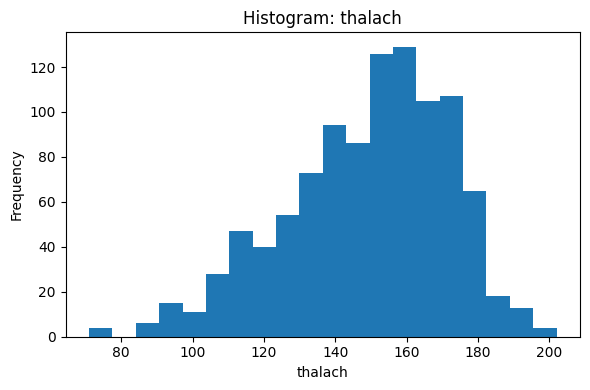

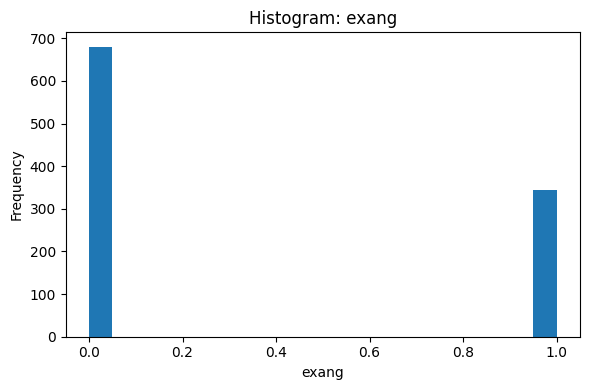

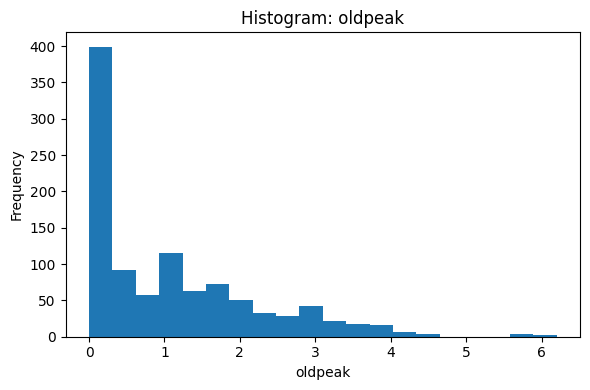

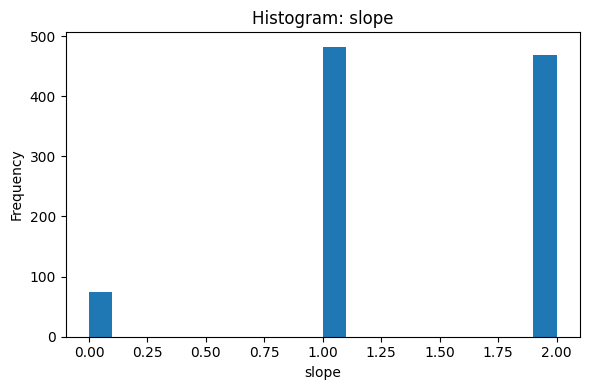

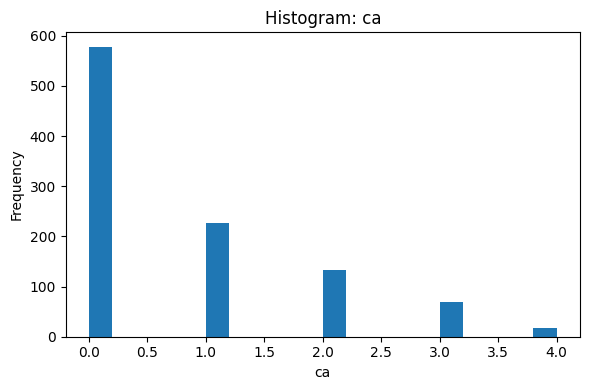

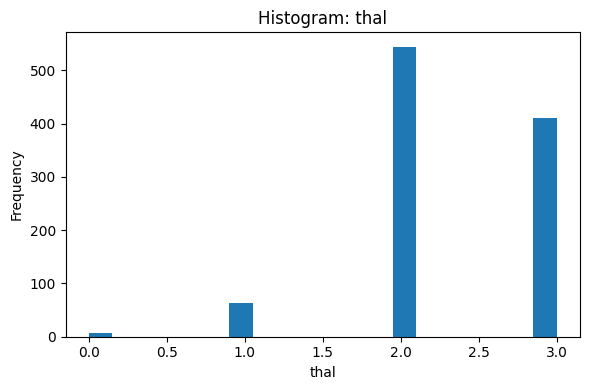

In [27]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target from distribution plots (optional)
numeric_feature_cols = [c for c in numeric_cols if c != "target"]

for col in numeric_feature_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 8) Outliers & Spread (Box Plots)

Box plots help detect outliers and compare the spread of each numeric feature.


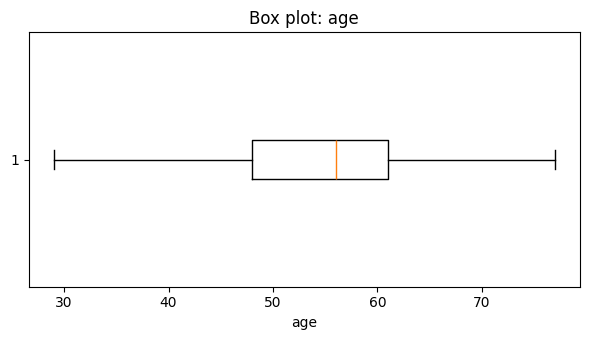

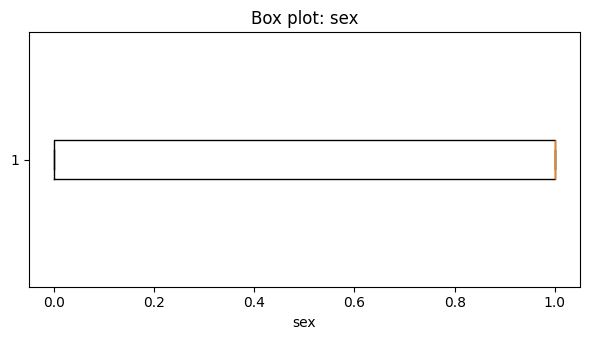

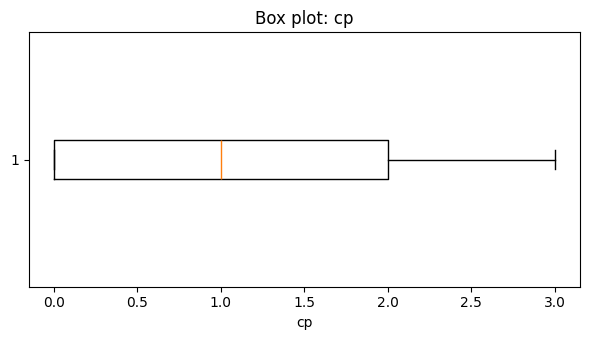

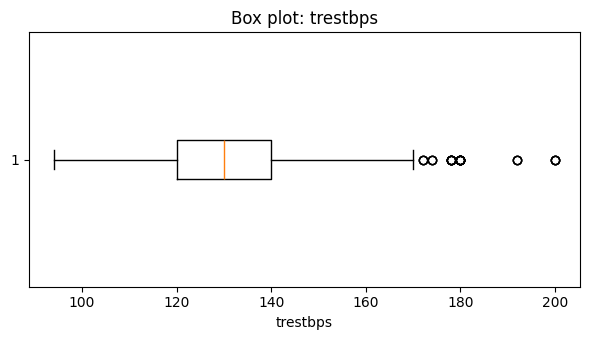

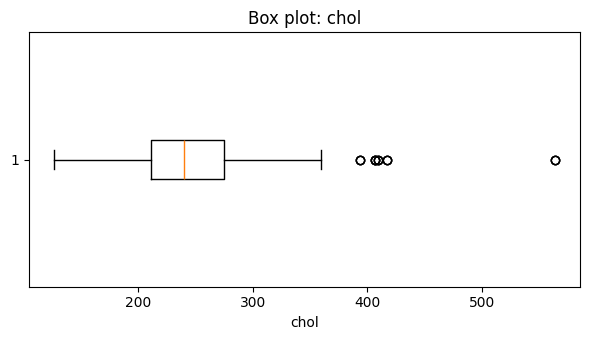

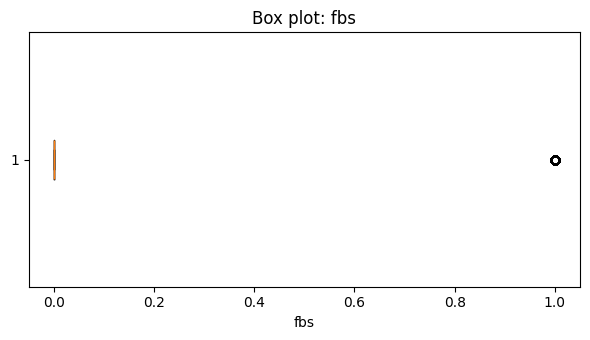

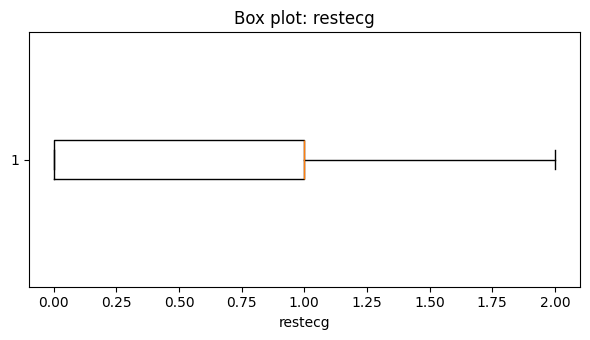

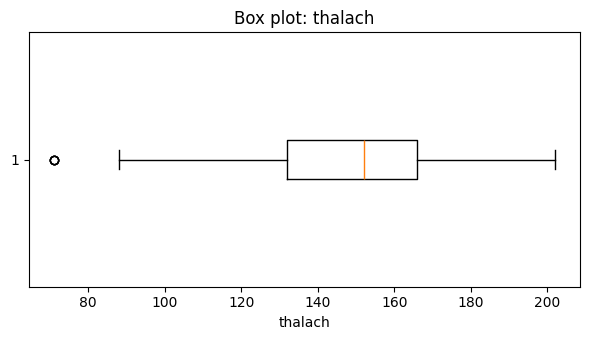

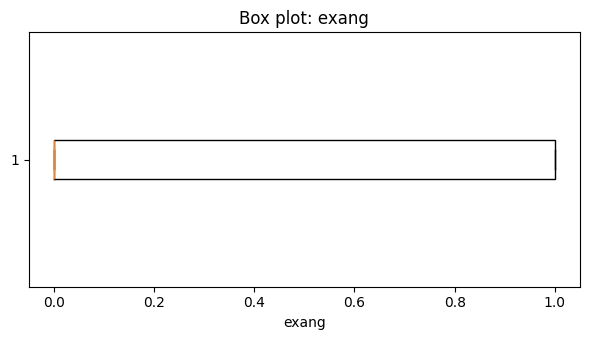

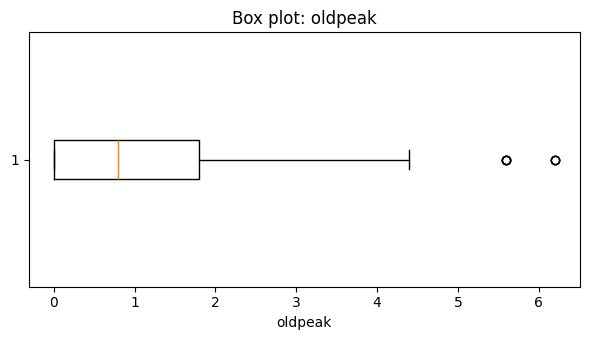

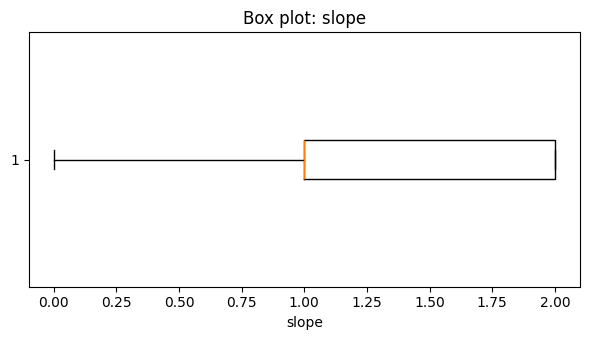

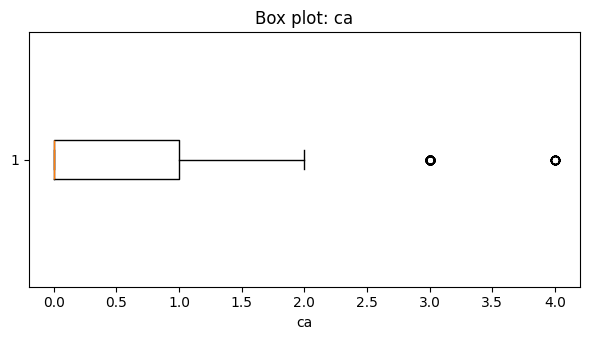

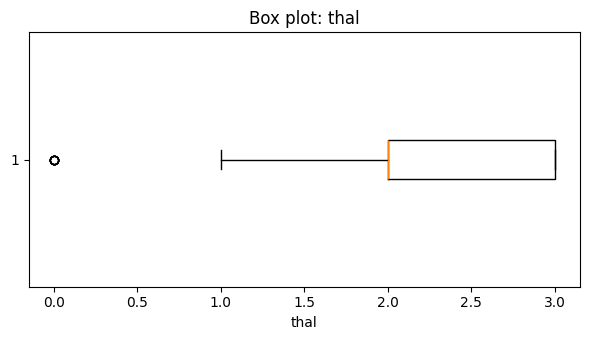

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_feature_cols:
    plt.figure(figsize=(6,3.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box plot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 9) Correlation Analysis

We compute correlations between numeric features and visualize them as a heatmap.  
This helps identify strongly related variables and potential predictive signals for modeling.


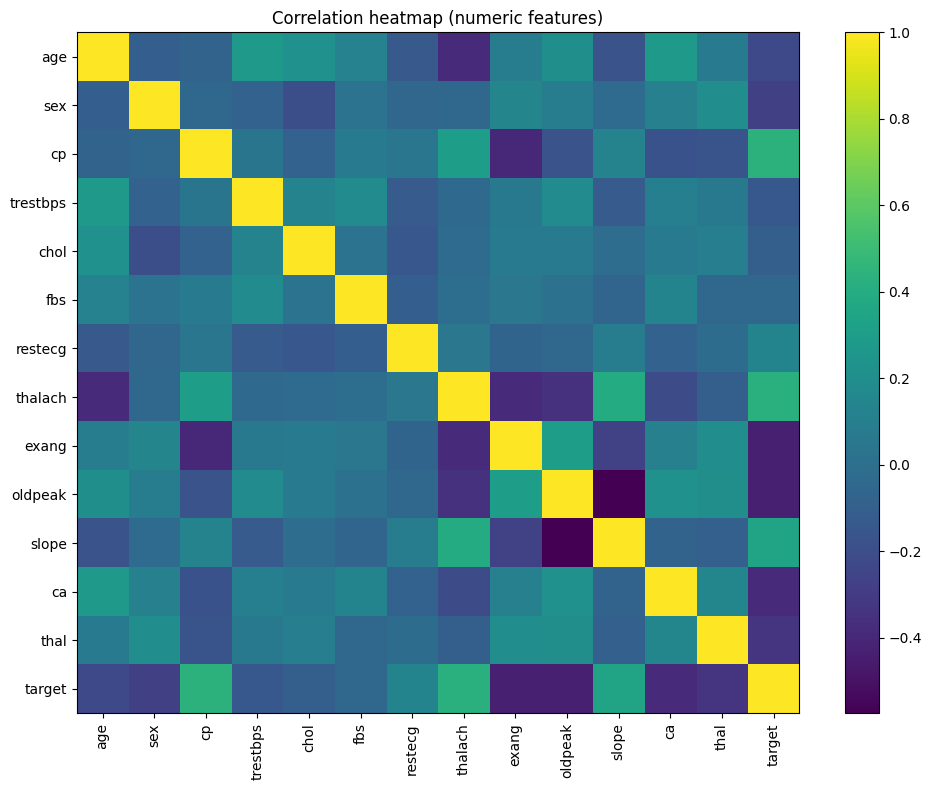

Top correlations with target (by absolute value):


,corr_with_target
oldpeak,-0.438441
exang,-0.438029
cp,0.434854
thalach,0.422895
ca,-0.382085
slope,0.345512
thal,-0.337838
sex,-0.279501
age,-0.229324
trestbps,-0.138772


In [29]:
import numpy as np
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

# Show top correlations with the target (if target is numeric 0/1)
if "target" in corr.columns:
    target_corr = corr["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
    print("Top correlations with target (by absolute value):")
    display(target_corr.to_frame("corr_with_target"))

## 10) Feature vs Target (Group Comparison)

We compare numeric feature means across the two target classes (0 vs 1) to get an initial sense of which features differ between classes.

In [30]:
import numpy as np
group_means = df.groupby("target")[numeric_feature_cols].mean().T
group_means.columns = ["mean_target_0", "mean_target_1"]
group_means["diff_(1-0)"] = group_means["mean_target_1"] - group_means["mean_target_0"]
group_means.sort_values(by="diff_(1-0)", key=lambda s: s.abs(), ascending=False).head(20)

,mean_target_0,mean_target_1,diff_(1-0)
thalach,139.130261,158.585551,19.455291
chol,251.292585,240.979087,-10.313498
trestbps,134.106212,129.245247,-4.860965
age,56.569138,52.408745,-4.160393
oldpeak,1.600200,0.569962,-1.030238
cp,0.482966,1.378327,0.895361
ca,1.158317,0.370722,-0.787594
slope,1.166333,1.593156,0.426823
thal,2.539078,2.119772,-0.419306
exang,0.549098,0.134981,-0.414117


## 11) Key Insights & Challenges

Key findings from the EDA include:
- The dataset contains no missing values, indicating high completeness.
- Target classes are relatively balanced (526 vs 499), reducing class imbalance concerns.
- Several features show strong relationships with heart disease outcomes, particularly oldpeak, exang, chest pain type, and maximum heart rate.
- A potential challenge is the presence of outliers in some clinical measurements, which may require scaling or robust preprocessing in the next phase.

## 12) Data Preprocessing

### 12.1 Scaling
Continuous variables (age, trestbps, chol, thalach, and oldpeak), which represent continuous medical measurements with substantially different numeric scales, were standardized using Z-score transformation, defined as  
\( z = \frac{x - \mu}{\sigma} \),  
where \( \mu \) and \( \sigma \) denote the mean and standard deviation computed from the dataset itself. This transformation is therefore sample-based rather than derived from external clinical thresholds.

Although age is inherently interpretable in its raw form, it was standardized alongside other continuous variables to ensure balanced contribution across scale-sensitive classification models such as SVM and neural networks. This was done to place all continuous features on a comparable scale and prevent variables with larger ranges from dominating distance-based and gradient-based classification models. Z-score scaling was preferred over Min–Max normalization due to its lower sensitivity to outliers.


In [86]:
df = pd.read_excel(DATA_PATH)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Continuous variables (measured in different clinical units)
continuous_vars = ['age', 'trestbps', 'thalach', 'oldpeak']

# Table of original measurement units
units_table = pd.DataFrame({
    'Variable': continuous_vars,
    'Original Unit': [
        'Years',
        'mm Hg',
        'Beats per minute (bpm)',
        'ST depression (relative measurement)'
    ]
})

print(" Original Measurement Units:")
display(units_table)

# Store original values for comparison
df_before = df[continuous_vars].copy()

# Apply Z-score standardization:
# where μ and σ are computed from the dataset itself (sample-based scaling)
scaler = StandardScaler()
df[continuous_vars] = scaler.fit_transform(df[continuous_vars])

# Comparison table
comparison_table = pd.concat(
    [df_before.head(), df[continuous_vars].head()],
    axis=1,
    keys=['Before Scaling (with units)', 'After Scaling (unitless, relative to sample mean)']
)

print("\n Comparison (First 5 Rows):")
display(comparison_table)

# Verify distribution after scaling
scaling_summary = pd.DataFrame({
    'Mean After Scaling (≈ 0)': df[continuous_vars].mean(),
    'Std After Scaling (≈ 1)': df[continuous_vars].std()
})

print("\n Verification of Distribution-Based Scaling:")

# The table summarizes the mean and standard deviation for each continuous
# attribute after scaling, indicating that the features are now on a
# comparable scale.
display(scaling_summary)

 Original Measurement Units:


,Variable,Original Unit
0,age,Years
1,trestbps,mm Hg
2,thalach,Beats per minute (bpm)
3,oldpeak,ST depression (relative measurement)



 Comparison (First 5 Rows):


Before Scaling (with units)                           \
                          age trestbps thalach oldpeak   
0                          52      125     168     1.0   
1                          53      140     155     3.1   
2                          70      145     125     2.6   
3                          61      148     161     0.0   
4                          62      138     106     1.9   

  After Scaling (unitless, relative to sample mean)                      \
                                                age  trestbps   thalach   
0                                         -0.268437 -0.377636  0.821321   
1                                         -0.158157  0.479107  0.255968   
2                                          1.716595  0.764688 -1.048692   
3                                          0.724079  0.936037  0.516900   
4                                          0.834359  0.364875 -1.874977   

             
    oldpeak  
0 -0.060888  
1  1.727137  
2  1.301417  
3 -0.912329  
4  0.705408


 Verification of Distribution-Based Scaling:


,Mean After Scaling (≈ 0),Std After Scaling (≈ 1)
age,-3.431402e-16,1.000488
trestbps,-7.036106e-16,1.000488
thalach,-4.332578e-16,1.000488
oldpeak,-2.426243e-16,1.000488


### 12.2 Discretization
Discretization was not applied to most continuous variables to preserve numerical precision and the gradual nature of cardiovascular risk. However, cholesterol was discretized using established clinical thresholds, as cardiovascular risk is assessed based on risk categories (e.g., normal, borderline high, and high) rather than precise numeric values. As shown in Figure X, the presence of extreme cholesterol values further supports discretization to improve interpretability and reduce their influence.

**Figure X.** Distribution of cholesterol values showing the presence of clinically distinct risk ranges and extreme values.
![Cholesterol distribution](CholesterolMeasure.png)

In [88]:
import numpy as np
import pandas as pd

# Discretize cholesterol into clinically defined risk categories
chol_bins = [0, 200, 240, np.inf]
chol_labels = ['Normal', 'Borderline High', 'High']

df['chol_category'] = pd.cut(
    df['chol'],
    bins=chol_bins,
    labels=chol_labels,
    right=False
)

# Cholesterol risk category thresholds (clinical reference)
chol_mapping = pd.DataFrame({
    'Cholesterol Range (mg/dL)': ['< 200', '200–239', '≥ 240'],
    'Risk Category': chol_labels
})

# Distribution of cholesterol categories in the dataset
chol_distribution = (
    df['chol_category']
    .value_counts()
    .rename_axis('Cholesterol Category')
    .reset_index(name='Number of Patients')
)

display(chol_mapping)
display(chol_distribution)

# Remove original cholesterol values to avoid redundant representation
df.drop(columns=['chol'], inplace=True)

,Cholesterol Range (mg/dL),Risk Category
0,< 200,Normal
1,200–239,Borderline High
2,≥ 240,High


,Cholesterol Category,Number of Patients
0,High,517
1,Borderline High,339
2,Normal,169


### 12.3 Encoding
Categorical variables (cp, restecg, slope, ca, and thal) were encoded using one-hot encoding because their numerical values represent distinct medical categories rather than ordered or equally spaced quantities. Applying one-hot encoding prevents the models from assuming artificial linear ordering or equal distances between categories and allows them to learn the effect of each category on the classification outcome directly from the data.
Binary variables (sex, fbs, and exang) were retained in their original 0/1 format, as this representation is already suitable for classification models.

In [89]:
import pandas as pd

# Nominal and discretized categorical variables to encode
categorical_vars = ['cp', 'restecg', 'slope', 'ca', 'thal', 'chol_category']

print("Before Encoding:")
display(df.head())

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

# Convert to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nAfter Encoding:")
display(df.head())

Before Encoding:


,age,sex,cp,trestbps,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_category
0,-0.268437,1,0,-0.377636,0,1,0.821321,0,-0.060888,2,2,3,0,Borderline High
1,-0.158157,1,0,0.479107,1,0,0.255968,1,1.727137,0,0,3,0,Borderline High
2,1.716595,1,0,0.764688,0,1,-1.048692,1,1.301417,0,0,3,0,Normal
3,0.724079,1,0,0.936037,0,1,0.516900,0,-0.912329,2,1,3,0,Borderline High
4,0.834359,0,0,0.364875,1,1,-1.874977,0,0.705408,1,3,2,0,High



After Encoding:


,age,sex,trestbps,fbs,thalach,exang,oldpeak,target,cp_1,cp_2,...,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3,chol_category_Borderline High,chol_category_High
0,-0.268437,1,-0.377636,0,0.821321,0,-0.060888,0,0,0,...,1,0,1,0,0,0,0,1,1,0
1,-0.158157,1,0.479107,1,0.255968,1,1.727137,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,1.716595,1,0.764688,0,-1.048692,1,1.301417,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.724079,1,0.936037,0,0.516900,0,-0.912329,0,0,0,...,1,1,0,0,0,0,0,1,1,0
4,0.834359,0,0.364875,1,-1.874977,0,0.705408,0,0,0,...,0,0,0,1,0,0,1,0,0,1


### 12.4 Variable Removal
No variables were removed during preprocessing, as all features were clinically relevant and no variables exhibited constant values or excessive missing data. Removing variables without proper statistical or medical justification could result in unnecessary information loss and reduced predictive performance.